## Thelia的手撕线性回归尝试！

### 随机生成一个数据集吧~

In [667]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import time

n_samples = 50
seed = int(time.time())  # 每分钟更新一次随机种子，确保每次运行生成不同的样本
# 原函数参数 y = a * x + b
random.seed(seed)
a = random.uniform(-4, 4)
b = random.uniform(-10, 10)

# 方差与样本数（方差越大，点越分散）
noise_std = random.uniform(5, 10) * abs(a)
rng = np.random.default_rng(seed)
x = np.arange(1, n_samples + 1)
noise = rng.normal(0, noise_std, size=n_samples)
y = a * x + b + noise

df = pd.DataFrame({
    'x': x,
    'y': np.round(y, 1),
})

csv_path = Path('linear_regression_sample.csv')
df.to_csv(csv_path, index=False)
print(f'已生成 {n_samples} 条样本，保存到: {csv_path.resolve()}')
df.head()

已生成 50 条样本，保存到: /home/thelia/Learn/ML/MyCode/LearningMachineLearning/Thelia/linear_regression_sample.csv


,x,y
0,1,-20.4
1,2,-10.1
2,3,-31.5
3,4,23.4
4,5,9.8


### 导入包

In [668]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 导入数据

In [669]:
dataset = pd.read_csv('linear_regression_sample.csv')
print(dataset)
X = dataset.iloc[:, :-1].values #输入矩阵
y = dataset.iloc[:, -1].values #输出矩阵

     x      y
0    1  -20.4
1    2  -10.1
2    3  -31.5
3    4   23.4
4    5    9.8
5    6  -27.6
6    7  -41.6
7    8  -67.7
8    9  -15.2
9   10    0.3
10  11  -54.1
11  12  -60.2
12  13  -34.6
13  14  -79.0
14  15  -87.8
15  16  -63.4
16  17  -70.7
17  18  -59.0
18  19  -28.0
19  20  -88.4
20  21  -86.1
21  22  -60.0
22  23  -48.6
23  24  -73.7
24  25  -61.9
25  26 -134.3
26  27  -96.6
27  28  -27.2
28  29  -72.4
29  30  -53.2
30  31 -133.6
31  32  -72.4
32  33 -141.8
33  34 -101.6
34  35 -119.7
35  36  -81.0
36  37 -110.6
37  38 -134.4
38  39  -64.1
39  40 -126.8
40  41 -156.4
41  42 -116.7
42  43 -160.0
43  44 -174.8
44  45 -139.6
45  46 -181.9
46  47 -159.4
47  48 -128.5
48  49 -176.6
49  50 -140.2


#### 试着画个散点图？

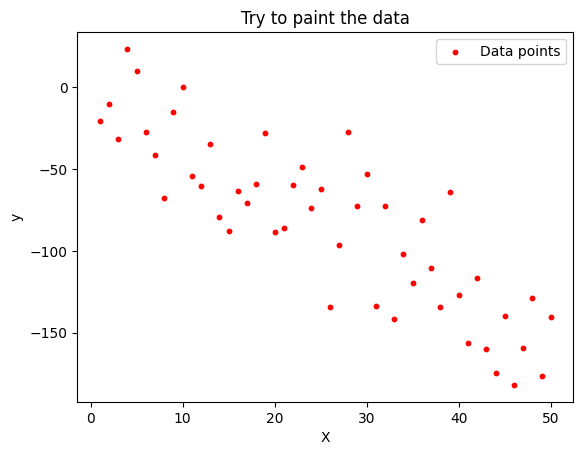

In [670]:
plt.scatter(X, y, color='red', s=10, label='Data points')
plt.title('Try to paint the data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

### 划分一下训练数据和测试数据~

In [671]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0) 

### 线性回归，启动！

In [672]:
class LinearRegression:
    def __init__(self, learning_rate=0.001, n_iters=30000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape #数据量&特征数
        # 初始化权重和偏置
        self.w = np.zeros(n_features)
        self.b = 0

        # 梯度下降
        for _ in range(self.n_iters):
            y_predicted = np.dot(X, self.w) + self.b
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

    def predict(self, X):
        linear_model = np.dot(X, self.w) + self.b
        return linear_model
        

### 训练一下

In [673]:
LM = LinearRegression()
LM.fit(X_train, y_train)

### 看看结果

Learned parameters: w=-3.2317, b=-5.1484
True parameters: a=-3.1769, b=-5.3797
Test MSE: 1441.9797


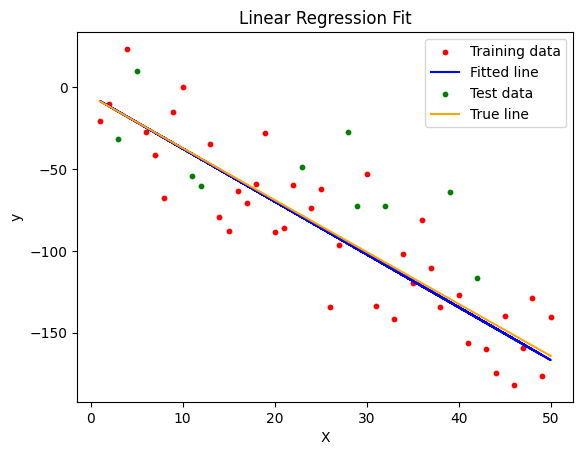

In [ ]:
plt.scatter(X_train, y_train, color='red', s=10, label='Training data')
plt.plot(X_train, LM.predict(X_train), color='blue', label='Fitted line')
plt.scatter(X_test, y_test, color='green', s=10, label='Test data')
plt.plot(X, a * X + b, color='orange', label='True line')
plt.title('Linear Regression Fit')
plt.xlabel('X')
plt.ylabel('y')
plt.legend(['Training data','Fitted line','Test data','True line'])
print(f'Learned parameters: w={LM.w[0]:.4f}, b={LM.b:.4f}')
print(f'True parameters: w={a:.4f}, b={b:.4f}')
print(f'Test MSE: {np.mean((LM.predict(X_test) - y_test) ** 2):.4f}')